
# Machine Learning Forecasting for USD/NGN Exchange Rate
This notebook complements the SARIMAX model by applying **machine learning** approaches — including Linear Regression, Ridge Regression, Random Forest, and Gradient Boosting — with feature engineering and hyperparameter tuning using `GridSearchCV`.


In [ ]:
# import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor 
from xgboost import XGBRegressor                                  
from lightgbm import LGBMRegressor                                
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
import warnings
import random

In [2]:
warnings.filterwarnings("ignore")
random.seed(12345)

In [3]:
# load features
df_feat = pd.read_csv('../../data/03_features/ngn_us_exchange_rates_features.csv')

# Display the feature engineered data
df_feat.head()

,Date,Rate,diff,lag_1,lag_2,lag_6,lag_8,lag_11,lag_13,lag_15,...,ret_3,ret_7,ret_14,ret_21,ret_30,ret_60,ret_90,month,day,year
0,1997-04-11,84.66,-0.29,0.00,0.00,-0.040,0.000,0.08,1.24,-0.22,...,-3.685185,-inf,-0.879167,-1.973154,-6.800000,-0.768000,-1.58,4,11,1997
1,1997-05-02,85.05,0.25,0.00,0.00,0.108,0.560,0.00,0.06,0.30,...,-1.862069,-0.722222,2.125000,-7.250000,inf,-1.297619,inf,5,2,1997
2,1997-05-09,84.48,-0.32,0.25,0.00,0.000,0.900,0.00,0.00,0.08,...,-inf,-3.962963,-6.333333,-inf,0.454545,-1.780488,-1.80,5,9,1997
3,1997-05-16,84.48,0.02,-0.32,0.25,0.000,0.108,-0.04,0.00,0.06,...,inf,inf,inf,-1.909091,-0.600000,-0.900000,-0.96,5,16,1997
4,1997-05-23,84.96,0.41,0.02,-0.32,-0.290,0.000,0.56,0.00,0.00,...,0.640000,inf,inf,-2.863636,-1.745455,inf,inf,5,23,1997


In [4]:
# Convert transaction_time column to date format
df_feat["Date"] = pd.to_datetime(df_feat["Date"], errors="coerce")
df_feat.set_index("Date", inplace=True)

In [5]:
# Replace infinities with NaN, inspect and clean
df_feat.replace([np.inf, -np.inf], 0, inplace=True)

In [6]:
# Train-test split (time split)
test_size = int(len(df_feat)*0.012)
train = df_feat.iloc[:-test_size].copy()
test = df_feat.iloc[-test_size:].copy()

print("Train range:", train.index.min().date(), "to", train.index.max().date())
print("Test range:", test.index.min().date(), "to", test.index.max().date())

Train range: 1997-04-11 to 2025-07-18
Test range: 2025-07-25 to 2025-10-17


In [7]:
# Summary statistics
df_feat.describe()

,Rate,diff,lag_1,lag_2,lag_6,lag_8,lag_11,lag_13,lag_15,lag_16,...,ret_3,ret_7,ret_14,ret_21,ret_30,ret_60,ret_90,month,day,year
count,1146.000000,1146.000000,1146.000000,1146.000000,1146.000000,1146.000000,1146.000000,1146.000000,1146.000000,1146.000000,...,1146.000000,1146.000000,1146.000000,1146.000000,1146.000000,1146.000000,1146.000000,1146.000000,1146.000000,1146.000000
mean,279.682016,-0.230045,-0.127287,-0.086624,-0.382568,-0.468742,-0.420691,-0.338026,-0.009632,-0.501462,...,-5.125664,0.183616,3.718248,-9.319961,2.964863,4.769597,-5.647065,6.602094,15.602967,2010.252182
std,356.856576,12.945168,12.844267,12.625612,9.605964,9.357957,8.999670,8.404755,11.797981,8.658302,...,111.981286,54.819408,110.525783,292.294192,72.000368,342.766880,121.988299,3.436073,8.782195,8.113610
min,74.425000,-145.530000,-145.530000,-145.530000,-145.530000,-145.530000,-145.530000,-145.530000,-145.530000,-145.530000,...,-3451.000000,-746.000000,-832.500000,-9524.000000,-626.000000,-5242.000000,-2155.000000,1.000000,1.000000,1997.000000
25%,126.175000,-0.300000,-0.200000,-0.200000,-0.190000,-0.190000,-0.150000,-0.157500,-0.150000,-0.200000,...,-1.619363,-1.600000,-1.431383,-1.499138,-1.380962,-1.329365,-1.384615,4.000000,8.000000,2003.000000
50%,151.355000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.730303,-0.721111,-0.654859,-0.640896,-0.666080,-0.733333,-0.674603,7.000000,16.000000,2010.000000
75%,304.200000,0.300000,0.207500,0.207500,0.210000,0.200000,0.200000,0.200000,0.200000,0.180000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000,23.000000,2016.000000
max,1681.390000,287.900000,287.900000,287.900000,95.230000,95.230000,95.230000,95.230000,287.900000,95.230000,...,374.000000,1430.000000,2909.600000,1049.000000,1525.000000,9616.000000,871.424242,12.000000,31.000000,2025.000000


In [8]:
# Show feature columns
df_feat .columns

Index(['Rate', 'diff', 'lag_1', 'lag_2', 'lag_6', 'lag_8', 'lag_11', 'lag_13',
       'lag_15', 'lag_16', 'lag_25', 'lag_32', 'lag_34', 'rmean_4', 'rstd_4',
       'rmean_8', 'rstd_8', 'rmean_12', 'rstd_12', 'ret_3', 'ret_7', 'ret_14',
       'ret_21', 'ret_30', 'ret_60', 'ret_90', 'month', 'day', 'year'],
      dtype='object')

In [ ]:
# Get feature columns and target variable
feature_cols = [c for c in df_feat.columns if c not in ["Rate"]]
X_train, y_train = train[feature_cols], train["Rate"]
X_test, y_test = test[feature_cols], test["Rate"]

In [ ]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
# Evaluation Function
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    R2 = 1 - (np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2))
    print(f"{name} | MAE: {mae:.4f} | RMSE: {rmse:.4f} | MAPE: {mape:.2f}% | R2: {R2:.4f}")
    return {"Model": name, "MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": R2}



In [12]:
# Models + Grid Search
tscv = TimeSeriesSplit(n_splits=5)
results = []

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
results.append(evaluate_model("LinearRegression", y_test, lr.predict(X_test_scaled)))

ridge = Ridge()
param_grid = {"alpha": [0.1, 1.0, 10.0, 50.0, 100.0]}
ridge_search = GridSearchCV(ridge, param_grid, cv=tscv, scoring="neg_mean_absolute_error")
ridge_search.fit(X_train_scaled, y_train)
best_ridge = ridge_search.best_estimator_
results.append(evaluate_model("Ridge", y_test, best_ridge.predict(X_test_scaled)))

rf = RandomForestRegressor(random_state=42)
rf_params = {"n_estimators": [100, 200], "max_depth": [5, 10, 20], "min_samples_split": [2, 5, 10]}
rf_search = GridSearchCV(rf, rf_params, cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1)
rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_
results.append(evaluate_model("RandomForest", y_test, best_rf.predict(X_test)))

gbr = GradientBoostingRegressor(random_state=42)
gbr_params = {"n_estimators": [100, 200], "learning_rate": [0.01, 0.05, 0.1], "max_depth": [3, 5]}
gbr_search = GridSearchCV(gbr, gbr_params, cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1)
gbr_search.fit(X_train, y_train)
best_gbr = gbr_search.best_estimator_
results.append(evaluate_model("GradientBoosting", y_test, best_gbr.predict(X_test)))

extra_trees = ExtraTreesRegressor(random_state=42)
et_params = {"n_estimators": [100, 200], "max_depth": [5, 10, 20], "min_samples_split": [2, 5, 10]}
et_search = GridSearchCV(extra_trees, et_params, cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1)
et_search.fit(X_train, y_train)
best_et = et_search.best_estimator_
results.append(evaluate_model("ExtraTrees", y_test, best_et.predict(X_test)))

xgbr = XGBRegressor(random_state=42, objective='reg:squarederror')
xgb_params = {"n_estimators": [100, 200], "learning_rate": [0.01, 0.05, 0.1], "max_depth": [3, 5]}
xgb_search = GridSearchCV(xgbr, xgb_params, cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1)
xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_   
results.append(evaluate_model("XGBoost", y_test, best_xgb.predict(X_test))) 

lgbm = LGBMRegressor(random_state=42, verbose=-1)
lgbm_params = {"n_estimators": [100, 200], "learning_rate": [0.01, 0.05, 0.1], "max_depth": [3, 5]}
lgbm_search = GridSearchCV(lgbm, lgbm_params, cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1)                    
lgbm_search.fit(X_train, y_train)
best_lgbm = lgbm_search.best_estimator_
results.append(evaluate_model("LightGBM", y_test, best_lgbm.predict(X_test)))

catboost = CatBoostRegressor(random_state=42, verbose=0)
catboost_params = {"iterations": [100, 200], "learning_rate": [0.01, 0.05, 0.1], "depth": [3, 5]}
catboost_search = GridSearchCV(catboost, catboost_params, cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1)
catboost_search.fit(X_train, y_train)
best_catboost = catboost_search.best_estimator_
results.append(evaluate_model("CatBoost", y_test, best_catboost.predict(X_test)))   

LinearRegression | MAE: 950.6780 | RMSE: 905018.4754 | MAPE: 63.02% | R2: -1171.2893
Ridge | MAE: 950.6842 | RMSE: 905030.1219 | MAPE: 63.02% | R2: -1171.3044
RandomForest | MAE: 37.1366 | RMSE: 2154.2927 | MAPE: 2.50% | R2: -1.7905
GradientBoosting | MAE: 50.3528 | RMSE: 3144.3557 | MAPE: 3.36% | R2: -3.0729
ExtraTrees | MAE: 34.7849 | RMSE: 1504.4977 | MAPE: 2.32% | R2: -0.9488
XGBoost | MAE: 62.3649 | RMSE: 5260.9766 | MAPE: 4.16% | R2: -5.8147
LightGBM | MAE: 38.6336 | RMSE: 2385.6616 | MAPE: 2.57% | R2: -2.0902
CatBoost | MAE: 32.7305 | RMSE: 1281.3312 | MAPE: 2.18% | R2: -0.6597


In [13]:
# Results Summary
results_df = pd.DataFrame(results).sort_values("MAE")
display(results_df)

,Model,MAE,RMSE,MAPE,R2
7,CatBoost,32.730541,1281.331169,2.178918,-0.659735
4,ExtraTrees,34.784905,1504.497651,2.324659,-0.948807
2,RandomForest,37.136629,2154.292660,2.495872,-1.790500
6,LightGBM,38.633578,2385.661606,2.573107,-2.090197
3,GradientBoosting,50.352776,3144.355709,3.360454,-3.072949
5,XGBoost,62.364947,5260.976648,4.161328,-5.814653
0,LinearRegression,950.677996,905018.475450,63.019459,-1171.289291
1,Ridge,950.684162,905030.121945,63.019854,-1171.304377


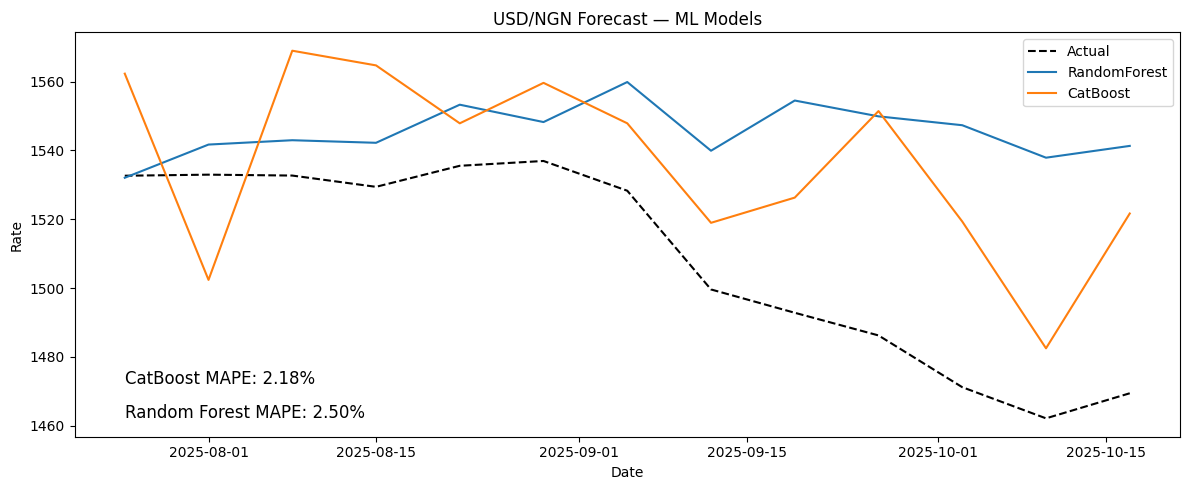

In [ ]:
# Plot Predictions
plt.figure(figsize=(12,5))
plt.plot(test.index, y_test, label="Actual", color="black", linestyle="--")
plt.plot(test.index, best_rf.predict(X_test), label="RandomForest")
# plt.plot(test.index, best_gbr.predict(X_test), label="GradientBoosting")
# plt.plot(test.index, best_et.predict(X_test), label="ExtraTrees")
# plt.plot(test.index, best_xgb.predict(X_test), label="XGBoost")
# plt.plot(test.index, best_lgbm.predict(X_test), label="LightGBM")
plt.plot(test.index, best_catboost.predict(X_test), label="CatBoost")   
# plt.plot(test.index, lr.predict(X_test_scaled), label="LinearRegression", linestyle="--")
# plt.plot(test.index, best_ridge.predict(X_test_scaled), label="Ridge", linestyle="--")
# add the MAPE to the plot
rf_mape = results_df[results_df["Model"]=="RandomForest"]["MAPE"].values[0]
catboost_mape = results_df[results_df["Model"]=="CatBoost"]["MAPE"].values[0]
plt.text(test.index[0], min(y_test), f"Random Forest MAPE: {rf_mape:.2f}%", fontsize=12, color="black")
plt.text(test.index[0], min(y_test) + 10, f"CatBoost MAPE: {catboost_mape:.2f}%", fontsize=12, color="black")
plt.legend()
plt.title("USD/NGN Forecast — ML Models")
plt.xlabel("Date")
plt.ylabel("Rate")
plt.tight_layout()
plt.show()

In [ ]:
# Save Outputs
# out = test[["date", "rate"]].copy()
# out["LinearRegression"] = lr.predict(X_test_scaled)
# out["Ridge"] = best_ridge.predict(X_test_scaled)
# out["RandomForest"] = best_rf.predict(X_test)
# out["GradientBoosting"] = best_gbr.predict(X_test)
# out.to_csv("ml_forex_forecasts.csv", index=False)
# print("Forecasts saved to ml_forex_forecasts.csv")

# print("\nBest model:", results_df.iloc[0]["Model"])